# Generation of data for training net

In [1]:
from polar_codes.channels.bpsk_awgn_channel import BpskAwgnChannel
import numpy as np
from numpy import save
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from polar_codes.PAC_code import PACCode
from polar_codes.rate_profile import rateprofile
import polar_codes.polar_coding_functions as pcf
import datetime
import time

In [2]:
epochs = 500            # (16,8) 收敛快, 500 够了
print_time = 5

In [3]:
current_datetime = datetime.datetime.now()
formatted_datetime = current_datetime.strftime("%Y-%m-%d-%H-%M")
x_file_name_prefix = "X_save_data_"
y_file_name_prefix = "Y_save_data_"
file_extension = ".npy"
x_save_file_name = f"{x_file_name_prefix}_{formatted_datetime}{file_extension}"
y_save_file_name = f"{y_file_name_prefix}_{formatted_datetime}{file_extension}"
print(x_save_file_name)
print(y_save_file_name)

X_save_data__2026-05-05-19-35.npy
Y_save_data__2026-05-05-19-35.npy


In [4]:
Model_Flag = False
Data_Flag  = False
log_dir    = 'file_2024-04-12-19-07.path'
save_fileX = 'X_save_data__2024-04-12-16-01.npy'
save_fileY = 'y_save_data__2024-04-12-16-01.npy'
Test_Model = 'Diffusion'
LLR_Model  = 'Calc'
n  = 4              # log2(16) = 4
N  = 16
K  = 8
R  = K / N          # = 0.5
batch = 4096
conv_gen = [1,0,1,1,0,1,1]
mem = len(conv_gen)-1
num_of_data = 2**21    # 100 万样本: 每个码字平均 ~4000 次 (查表友好)
X = np.zeros([num_of_data, N], dtype=np.float32)   # N=16 维信道 LLR
Y = np.zeros([num_of_data, K], dtype=np.float32)   # K=8 维 u 的 BPSK

In [5]:
def ten_binary(a, length=K):
    """Convert decimal `a` into a binary list of length `length` (MSB first).
    Generalised so it works for any K (was hard-coded to 8)."""
    m = [0] * length
    j = 0
    while a > 0:
        m[j] = a % 2
        a = a // 2
        j += 1
    return m[::-1]

In [6]:
def generate(n, K, num_of_data):
    """PAC(16,8) 训练数据生成. 多 SNR 混合训练增强泛化.

    搜索空间 2^8=256 个码字, 1M 样本下每个码字平均出现 ~4000 次,
    网络容量充裕, 不会过拟合, 可以用宽 SNR 范围.
    """
    train_snrs = [1.0, 2.0, 3.0, 4.0, 5.0]
    rprofile_list = [rateprofile(N, K, s) for s in train_snrs]
    code_list     = [PACCode(N=N, K=K, construct='rm-polar', dSNR=s, rprofile=rp)
                     for s, rp in zip(train_snrs, rprofile_list)]
    channel_list  = [BpskAwgnChannel(s, R) for s in train_snrs]

    snr_counts = [0] * len(train_snrs)
    for i in range(0, num_of_data):
        snr_idx = np.random.randint(0, len(train_snrs))
        channel = channel_list[snr_idx]
        code    = code_list[snr_idx]
        snr_counts[snr_idx] += 1

        u_message = np.asarray([0 if np.random.random_sample() > 0.5 else 1 for _ in range(0, K)], dtype='uint8')
        x_message = code.pac_encode(u_message, conv_gen, mem)
        to_message   = channel.modulate(x_message)
        from_message = channel.transmit(to_message)
        if LLR_Model == 'Hard':
            y_message = channel.demodulate(from_message)
        elif LLR_Model == 'Dire':
            y_message = from_message
        elif LLR_Model == 'Calc':
            y_message = channel.cal_llr(from_message)
        else:
            raise SystemExit('Please select the correct input')

        u_bpsk = np.where(u_message == 1, -1.0, 1.0).astype(np.float32)
        X[i] = y_message.astype(np.float32)
        Y[i] = u_bpsk

    print(f"PAC({N},{K}) Training SNRs: {train_snrs} dB")
    print(f"Distribution: " + ", ".join(f"{s}dB={c}" for s,c in zip(train_snrs, snr_counts)))
    print(f"X: {X.shape}, Y: {Y.shape}")

In [7]:
if Data_Flag:
    print('Load storage data')
else:
    print('Generate data')
    generate(n, K, num_of_data)

Generate data
PAC(16,8) Training SNRs: [1.0, 2.0, 3.0, 4.0, 5.0] dB
Distribution: 1.0dB=419472, 2.0dB=419984, 3.0dB=419385, 4.0dB=419100, 5.0dB=419211
X: (2097152, 16), Y: (2097152, 8)


In [8]:
if Data_Flag:
    print('No new data')    
else:
    print('Save new data')  
    save(x_save_file_name, X) #Save training data
    save(y_save_file_name, Y) #Save label data

Save new data


# Network

In [9]:

class Net(nn.Module):
    def __init__(self, input_size=64, output_size=32):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256, momentum=.9999)
        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256, momentum=.9999)
        self.fc3 = nn.Linear(256, 256)
        self.bn3 = nn.BatchNorm1d(256, momentum=.9999)
        self.fc4 = nn.Linear(256, output_size)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.bn1(x)
        x = F.relu(self.fc2(x))
        x = self.bn2(x)
        x = F.relu(self.fc3(x))
        x = self.bn3(x)
        x = self.sigmoid(self.fc4(x))
        return x

In [10]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half_dim, device=device).float() / half_dim
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
        return emb


class ResBlock(nn.Module):
    def __init__(self, hidden, time_emb_dim):
        super().__init__()
        self.fc1 = nn.Linear(hidden, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.norm1 = nn.LayerNorm(hidden)
        self.norm2 = nn.LayerNorm(hidden)
        self.time_proj = nn.Linear(time_emb_dim, hidden)
        self.act = nn.SiLU()
    def forward(self, x, t_emb):
        h = self.norm1(x); h = self.act(h); h = self.fc1(h)
        h = h + self.time_proj(self.act(t_emb))
        h = self.norm2(h); h = self.act(h); h = self.fc2(h)
        return x + h


class DiffusionNet(nn.Module):
    """双头扩散网络 for PAC(16,8).

    架构:
        - 共享 y_cond 编码器 (N=16 -> hidden)
        - 主头 (epsilon): noisy_u + y_feat + time_emb -> eps_pred
        - 辅助头 (info): y_feat -> u logits (强迫 y -> u 通路)

    规模匹配 PAC(16,8): hidden=256, blocks=4, ~2-3M 参数
    """
    def __init__(self, N=16, K=8, hidden=256, time_emb_dim=128, n_blocks=4):
        super().__init__()
        self.N = N; self.K = K

        self.time_embed = SinusoidalTimeEmbedding(time_emb_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # y_cond 编码器
        self.y_encoder = nn.Sequential(
            nn.Linear(N, hidden),
            nn.LayerNorm(hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
        )

        # 辅助头
        self.info_head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden // 2),
            nn.SiLU(),
            nn.Linear(hidden // 2, K),
        )

        # 主头
        self.u_proj = nn.Linear(K, hidden)
        self.merge  = nn.Linear(2 * hidden, hidden)
        self.blocks = nn.ModuleList([ResBlock(hidden, time_emb_dim) for _ in range(n_blocks)])
        self.out_norm = nn.LayerNorm(hidden)
        self.out_proj = nn.Linear(hidden, K)
        self.act = nn.SiLU()

    def encode_y(self, y_cond):
        return self.y_encoder(y_cond)

    def info_predict(self, y_cond):
        y_feat = self.encode_y(y_cond)
        return self.info_head(y_feat)

    def forward(self, noisy_u, y_cond, t):
        t_emb = self.time_embed(t)
        t_emb = self.time_mlp(t_emb)
        y_feat = self.encode_y(y_cond)
        u_feat = self.u_proj(noisy_u)
        h = torch.cat([u_feat, y_feat], dim=-1)
        h = self.merge(h)
        for block in self.blocks:
            h = block(h, t_emb)
        h = self.out_norm(h); h = self.act(h)
        return self.out_proj(h)

In [11]:
class RNN_Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(RNN_Net, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=False)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        h0 = h0.to(device)
        c0 = c0.to(device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        out = self.sigmoid(out)
        return out

In [12]:
class CNN_Net(nn.Module):
    def __init__(self):
        super(CNN_Net, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=128,
                kernel_size=[1, 4],   # 1x4
                # stride=1,
                padding='same'
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=[1, 2], stride=[1, 2])
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(
                in_channels=128,
                out_channels=64,
                kernel_size=[1, 4],
                # stride=1,
                padding='same'
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=[1, 2], stride=[1, 2])
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(
                in_channels=64,
                out_channels=16,
                kernel_size=[1, 4],
                # stride=1,
                padding='same'
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=[1, 2], stride=[1, 2])
        )
        # After 3 maxpool/2 along the last dim, length = N / 8.
        # For N=64 this gives 8, so flattened size = 16 * 1 * 8 = 128.
        self.output = nn.Linear(in_features=16 * 1 * (N // 8), out_features=K)
        self.active = nn.Sigmoid()

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        output = self.output(x)
        output = self.active(output)
        return output

In [13]:
class DiffusionModelWrapper(nn.Module):
    def __init__(self, base_model, scheduler, device):
        super().__init__()
        self.base_model = base_model
        self.scheduler  = scheduler
        self.device     = device

    def forward(self, noisy_u, y_cond, t):
        return self.base_model(noisy_u, y_cond, t)

# Training

In [14]:
if Data_Flag:
    X = np.load(save_fileX)
    Y = np.load(save_fileY)
    print('Load data！')
else:
    X = np.load(x_save_file_name)
    Y = np.load(y_save_file_name)
    print('No storage data！')

No storage data！


In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/4, random_state=42)

In [16]:
# Copyright 2023 UC Berkeley Team and The HuggingFace Team. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# DISCLAIMER: This file is strongly influenced by https://github.com/ermongroup/ddim

import math
from dataclasses import dataclass
from typing import List, Optional, Tuple, Union

import numpy as np
import torch

from diffusers.configuration_utils import ConfigMixin, register_to_config
from diffusers.utils import BaseOutput
from diffusers.utils.torch_utils import randn_tensor
from diffusers.schedulers import KarrasDiffusionSchedulers, SchedulerMixin



@dataclass
class DDPMSchedulerOutput(BaseOutput):

    prev_sample: torch.FloatTensor
    pred_original_sample: Optional[torch.FloatTensor] = None


def betas_for_alpha_bar(
    num_diffusion_timesteps,
    max_beta=0.999,
    alpha_transform_type="cosine",
):
    if alpha_transform_type == "cosine":

        def alpha_bar_fn(t):
            return math.cos((t + 0.008) / 1.008 * math.pi / 2) ** 2

    elif alpha_transform_type == "exp":

        def alpha_bar_fn(t):
            return math.exp(t * -12.0)

    else:
        raise ValueError(f"Unsupported alpha_tranform_type: {alpha_transform_type}")

    betas = []
    for i in range(num_diffusion_timesteps):
        t1 = i / num_diffusion_timesteps
        t2 = (i + 1) / num_diffusion_timesteps
        betas.append(min(1 - alpha_bar_fn(t2) / alpha_bar_fn(t1), max_beta))
    return torch.tensor(betas, dtype=torch.float32)


# Copied from diffusers.schedulers.scheduling_ddim.rescale_zero_terminal_snr
def rescale_zero_terminal_snr(betas):
    # Convert betas to alphas_bar_sqrt
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_bar_sqrt = alphas_cumprod.sqrt()

    # Store old values.
    alphas_bar_sqrt_0 = alphas_bar_sqrt[0].clone()
    alphas_bar_sqrt_T = alphas_bar_sqrt[-1].clone()

    # Shift so the last timestep is zero.
    alphas_bar_sqrt -= alphas_bar_sqrt_T

    # Scale so the first timestep is back to the old value.
    alphas_bar_sqrt *= alphas_bar_sqrt_0 / (alphas_bar_sqrt_0 - alphas_bar_sqrt_T)

    # Convert alphas_bar_sqrt to betas
    alphas_bar = alphas_bar_sqrt**2  # Revert sqrt
    alphas = alphas_bar[1:] / alphas_bar[:-1]  # Revert cumprod
    alphas = torch.cat([alphas_bar[0:1], alphas])
    betas = 1 - alphas

    return betas


class DDPMScheduler(SchedulerMixin, ConfigMixin):

    _compatibles = [e.name for e in KarrasDiffusionSchedulers]
    order = 1

    @register_to_config
    def __init__(
        self,
        num_train_timesteps: int = 1000,
        beta_start: float = 0.0001,
        beta_end: float = 0.02,
        beta_schedule: str = "linear",
        trained_betas: Optional[Union[np.ndarray, List[float]]] = None,
        variance_type: str = "fixed_small",
        clip_sample: bool = True,
        prediction_type: str = "epsilon",
        thresholding: bool = False,
        dynamic_thresholding_ratio: float = 0.995,
        clip_sample_range: float = 1.0,
        sample_max_value: float = 1.0,
        timestep_spacing: str = "leading",
        steps_offset: int = 0,
        rescale_betas_zero_snr: int = False,
    ):
        if trained_betas is not None:
            self.betas = torch.tensor(trained_betas, dtype=torch.float32)
        elif beta_schedule == "linear":
            self.betas = torch.linspace(beta_start, beta_end, num_train_timesteps, dtype=torch.float32)
        elif beta_schedule == "scaled_linear":
            # this schedule is very specific to the latent diffusion model.
            self.betas = torch.linspace(beta_start**0.5, beta_end**0.5, num_train_timesteps, dtype=torch.float32) ** 2
        elif beta_schedule == "squaredcos_cap_v2":
            # Glide cosine schedule
            self.betas = betas_for_alpha_bar(num_train_timesteps)
        elif beta_schedule == "sigmoid":
            # GeoDiff sigmoid schedule
            betas = torch.linspace(-6, 6, num_train_timesteps)
            self.betas = torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
        else:
            raise NotImplementedError(f"{beta_schedule} does is not implemented for {self.__class__}")

        # Rescale for zero SNR
        if rescale_betas_zero_snr:
            self.betas = rescale_zero_terminal_snr(self.betas)

        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.one = torch.tensor(1.0)

        # standard deviation of the initial noise distribution
        self.init_noise_sigma = 1.0

        # setable values
        self.custom_timesteps = False
        self.num_inference_steps = None
        self.timesteps = torch.from_numpy(np.arange(0, num_train_timesteps)[::-1].copy())

        self.variance_type = variance_type

    def scale_model_input(self, sample: torch.FloatTensor, timestep: Optional[int] = None) -> torch.FloatTensor:
        return sample

    def set_timesteps(
        self,
        num_inference_steps: Optional[int] = None,
        device: Union[str, torch.device] = None,
        timesteps: Optional[List[int]] = None,
    ):
        if num_inference_steps is not None and timesteps is not None:
            raise ValueError("Can only pass one of `num_inference_steps` or `custom_timesteps`.")

        if timesteps is not None:
            for i in range(1, len(timesteps)):
                if timesteps[i] >= timesteps[i - 1]:
                    raise ValueError("`custom_timesteps` must be in descending order.")

            if timesteps[0] >= self.config.num_train_timesteps:
                raise ValueError(
                    f"`timesteps` must start before `self.config.train_timesteps`:"
                    f" {self.config.num_train_timesteps}."
                )

            timesteps = np.array(timesteps, dtype=np.int64)
            self.custom_timesteps = True
        else:
            if num_inference_steps > self.config.num_train_timesteps:
                raise ValueError(
                    f"`num_inference_steps`: {num_inference_steps} cannot be larger than `self.config.train_timesteps`:"
                    f" {self.config.num_train_timesteps} as the unet model trained with this scheduler can only handle"
                    f" maximal {self.config.num_train_timesteps} timesteps."
                )

            self.num_inference_steps = num_inference_steps
            self.custom_timesteps = False

            # "linspace", "leading", "trailing" corresponds to annotation of Table 2. of https://arxiv.org/abs/2305.08891
            if self.config.timestep_spacing == "linspace":
                timesteps = (
                    np.linspace(0, self.config.num_train_timesteps - 1, num_inference_steps)
                    .round()[::-1]
                    .copy()
                    .astype(np.int64)
                )
            elif self.config.timestep_spacing == "leading":
                step_ratio = self.config.num_train_timesteps // self.num_inference_steps
                # creates integer timesteps by multiplying by ratio
                # casting to int to avoid issues when num_inference_step is power of 3
                timesteps = (np.arange(0, num_inference_steps) * step_ratio).round()[::-1].copy().astype(np.int64)
                timesteps += self.config.steps_offset
            elif self.config.timestep_spacing == "trailing":
                step_ratio = self.config.num_train_timesteps / self.num_inference_steps
                # creates integer timesteps by multiplying by ratio
                # casting to int to avoid issues when num_inference_step is power of 3
                timesteps = np.round(np.arange(self.config.num_train_timesteps, 0, -step_ratio)).astype(np.int64)
                timesteps -= 1
            else:
                raise ValueError(
                    f"{self.config.timestep_spacing} is not supported. Please make sure to choose one of 'linspace', 'leading' or 'trailing'."
                )

        self.timesteps = torch.from_numpy(timesteps).to(device)

    def _get_variance(self, t, predicted_variance=None, variance_type=None):
        prev_t = self.previous_timestep(t)

        alpha_prod_t = self.alphas_cumprod[t]
        alpha_prod_t_prev = self.alphas_cumprod[prev_t] if prev_t >= 0 else self.one
        current_beta_t = 1 - alpha_prod_t / alpha_prod_t_prev

        # For t > 0, compute predicted variance βt (see formula (6) and (7) from https://arxiv.org/pdf/2006.11239.pdf)
        # and sample from it to get previous sample
        # x_{t-1} ~ N(pred_prev_sample, variance) == add variance to pred_sample
        variance = (1 - alpha_prod_t_prev) / (1 - alpha_prod_t) * current_beta_t

        # we always take the log of variance, so clamp it to ensure it's not 0
        variance = torch.clamp(variance, min=1e-20)

        if variance_type is None:
            variance_type = self.config.variance_type

        # hacks - were probably added for training stability
        if variance_type == "fixed_small":
            variance = variance
        # for rl-diffuser https://arxiv.org/abs/2205.09991
        elif variance_type == "fixed_small_log":
            variance = torch.log(variance)
            variance = torch.exp(0.5 * variance)
        elif variance_type == "fixed_large":
            variance = current_beta_t
        elif variance_type == "fixed_large_log":
            # Glide max_log
            variance = torch.log(current_beta_t)
        elif variance_type == "learned":
            return predicted_variance
        elif variance_type == "learned_range":
            min_log = torch.log(variance)
            max_log = torch.log(current_beta_t)
            frac = (predicted_variance + 1) / 2
            variance = frac * max_log + (1 - frac) * min_log

        return variance

    def _threshold_sample(self, sample: torch.FloatTensor) -> torch.FloatTensor:
        dtype = sample.dtype
        batch_size, channels, *remaining_dims = sample.shape

        if dtype not in (torch.float32, torch.float64):
            sample = sample.float()  # upcast for quantile calculation, and clamp not implemented for cpu half

        # Flatten sample for doing quantile calculation along each image
        sample = sample.reshape(batch_size, channels * np.prod(remaining_dims))

        abs_sample = sample.abs()  # "a certain percentile absolute pixel value"

        s = torch.quantile(abs_sample, self.config.dynamic_thresholding_ratio, dim=1)
        s = torch.clamp(
            s, min=1, max=self.config.sample_max_value
        )  # When clamped to min=1, equivalent to standard clipping to [-1, 1]
        s = s.unsqueeze(1)  # (batch_size, 1) because clamp will broadcast along dim=0
        sample = torch.clamp(sample, -s, s) / s  # "we threshold xt0 to the range [-s, s] and then divide by s"

        sample = sample.reshape(batch_size, channels, *remaining_dims)
        sample = sample.to(dtype)

        return sample

    def step(
        self,
        model_output: torch.FloatTensor,
        timestep: int,
        sample: torch.FloatTensor,
        generator=None,
        no_variance=False,
        return_dict: bool = True,
    ) -> Union[DDPMSchedulerOutput, Tuple]:
        t = timestep

        prev_t = self.previous_timestep(t)

        if model_output.shape[1] == sample.shape[1] * 2 and self.variance_type in ["learned", "learned_range"]:
            model_output, predicted_variance = torch.split(model_output, sample.shape[1], dim=1)
        else:
            predicted_variance = None

        # 1. compute alphas, betas
        alpha_prod_t = self.alphas_cumprod[t]
        alpha_prod_t_prev = self.alphas_cumprod[prev_t] if prev_t >= 0 else self.one
        beta_prod_t = 1 - alpha_prod_t
        beta_prod_t_prev = 1 - alpha_prod_t_prev
        current_alpha_t = alpha_prod_t / alpha_prod_t_prev
        current_beta_t = 1 - current_alpha_t

        # 2. compute predicted original sample from predicted noise also called
        # "predicted x_0" of formula (15) from https://arxiv.org/pdf/2006.11239.pdf
        if self.config.prediction_type == "epsilon":
            pred_original_sample = (sample - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)
        elif self.config.prediction_type == "sample":
            pred_original_sample = model_output
        elif self.config.prediction_type == "v_prediction":
            pred_original_sample = (alpha_prod_t**0.5) * sample - (beta_prod_t**0.5) * model_output
        else:
            raise ValueError(
                f"prediction_type given as {self.config.prediction_type} must be one of `epsilon`, `sample` or"
                " `v_prediction`  for the DDPMScheduler."
            )

        # 3. Clip or threshold "predicted x_0"
        if self.config.thresholding:
            pred_original_sample = self._threshold_sample(pred_original_sample)
        elif self.config.clip_sample:
            pred_original_sample = pred_original_sample.clamp(
                -self.config.clip_sample_range, self.config.clip_sample_range
            )

        # 4. Compute coefficients for pred_original_sample x_0 and current sample x_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_original_sample_coeff = (alpha_prod_t_prev ** (0.5) * current_beta_t) / beta_prod_t
        current_sample_coeff = current_alpha_t ** (0.5) * beta_prod_t_prev / beta_prod_t

        # 5. Compute predicted previous sample µ_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_prev_sample = pred_original_sample_coeff * pred_original_sample + current_sample_coeff * sample

        # 6. Add noise
        variance = 0
        if t > 0 and not no_variance:
            device = model_output.device
            variance_noise = randn_tensor(
                model_output.shape, generator=generator, device=device, dtype=model_output.dtype
            )
            if self.variance_type == "fixed_small_log":
                variance = self._get_variance(t, predicted_variance=predicted_variance) * variance_noise
            elif self.variance_type == "learned_range":
                variance = self._get_variance(t, predicted_variance=predicted_variance)
                variance = torch.exp(0.5 * variance) * variance_noise
            else:
                variance = (self._get_variance(t, predicted_variance=predicted_variance) ** 0.5) * variance_noise
        pred_prev_sample = pred_prev_sample + variance
        if not return_dict:
            return (pred_prev_sample,)

        return DDPMSchedulerOutput(prev_sample=pred_prev_sample, pred_original_sample=pred_original_sample)

    def add_noise(
        self,
        original_samples: torch.FloatTensor,
        noise: torch.FloatTensor,
        timesteps: torch.IntTensor,
    ) -> torch.FloatTensor:
        # Make sure alphas_cumprod and timestep have same device and dtype as original_samples
        alphas_cumprod = self.alphas_cumprod.to(device=original_samples.device, dtype=original_samples.dtype)
        timesteps = timesteps.to(original_samples.device)

        sqrt_alpha_prod = alphas_cumprod[timesteps] ** 0.5
        sqrt_alpha_prod = sqrt_alpha_prod.flatten()
        while len(sqrt_alpha_prod.shape) < len(original_samples.shape):
            sqrt_alpha_prod = sqrt_alpha_prod.unsqueeze(-1)

        sqrt_one_minus_alpha_prod = (1 - alphas_cumprod[timesteps]) ** 0.5
        sqrt_one_minus_alpha_prod = sqrt_one_minus_alpha_prod.flatten()
        while len(sqrt_one_minus_alpha_prod.shape) < len(original_samples.shape):
            sqrt_one_minus_alpha_prod = sqrt_one_minus_alpha_prod.unsqueeze(-1)

        noisy_samples = sqrt_alpha_prod * original_samples + sqrt_one_minus_alpha_prod * noise
        return noisy_samples

    def get_velocity(
        self, sample: torch.FloatTensor, noise: torch.FloatTensor, timesteps: torch.IntTensor
    ) -> torch.FloatTensor:
        # Make sure alphas_cumprod and timestep have same device and dtype as sample
        alphas_cumprod = self.alphas_cumprod.to(device=sample.device, dtype=sample.dtype)
        timesteps = timesteps.to(sample.device)

        sqrt_alpha_prod = alphas_cumprod[timesteps] ** 0.5
        sqrt_alpha_prod = sqrt_alpha_prod.flatten()
        while len(sqrt_alpha_prod.shape) < len(sample.shape):
            sqrt_alpha_prod = sqrt_alpha_prod.unsqueeze(-1)

        sqrt_one_minus_alpha_prod = (1 - alphas_cumprod[timesteps]) ** 0.5
        sqrt_one_minus_alpha_prod = sqrt_one_minus_alpha_prod.flatten()
        while len(sqrt_one_minus_alpha_prod.shape) < len(sample.shape):
            sqrt_one_minus_alpha_prod = sqrt_one_minus_alpha_prod.unsqueeze(-1)

        velocity = sqrt_alpha_prod * noise - sqrt_one_minus_alpha_prod * sample
        return velocity

    def __len__(self):
        return self.config.num_train_timesteps

    def previous_timestep(self, timestep):
        if self.custom_timesteps:
            index = (self.timesteps == timestep).nonzero(as_tuple=True)[0][0]
            if index == self.timesteps.shape[0] - 1:
                prev_t = torch.tensor(-1)
            else:
                prev_t = self.timesteps[index + 1]
        else:
            num_inference_steps = (
                self.num_inference_steps if self.num_inference_steps else self.config.num_train_timesteps
            )
            prev_t = timestep - self.config.num_train_timesteps // num_inference_steps

        return prev_t


In [17]:
import torch
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

diffusion_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="linear",
    beta_start=0.0001,
    beta_end=0.02,
    prediction_type="epsilon",
    clip_sample=False
)

if Test_Model == 'CNN':
    dnn = CNN_Net().to(device); print("CNN")
elif Test_Model == 'RNN':
    dnn = RNN_Net(input_size=N, hidden_size=128, num_layers=1, output_size=K).to(device); print("RNN")
elif Test_Model == 'MLP':
    dnn = Net(input_size=N, output_size=K).to(device); print("MLP")
elif Test_Model == 'Diffusion':
    base_model = DiffusionNet(N=N, K=K, hidden=256, time_emb_dim=128, n_blocks=4).to(device)
    dnn = DiffusionModelWrapper(base_model, diffusion_scheduler, device)
    total = sum(p.nelement() for p in dnn.parameters())
    print(f"Dual-Head Diffusion for PAC({N},{K}): hidden=256, blocks=4, params={total/1e6:.1f}M")
else:
    print("Please select the correct model")

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Dual-Head Diffusion for PAC(16,8): hidden=256, blocks=4, params=1.0M


In [18]:
if str(device) == "cuda":
    print("The model runs on the GPU")
else:
    print("The model runs on the CPU")

The model runs on the GPU


In [19]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)   # K 维 ±1
Y_test  = torch.tensor(Y_test,  dtype=torch.float32)
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")

X_train: torch.Size([1572864, 16]), Y_train: torch.Size([1572864, 8])


In [20]:
print(X_test.shape)
print(X_train.shape)
print(Y_test.shape)
print(Y_train.shape)

torch.Size([524288, 16])
torch.Size([1572864, 16])
torch.Size([524288, 8])
torch.Size([1572864, 8])


In [21]:
# 整个数据集一次性搬到 GPU (Pro 6000 显存 96GB, N=64 时百万样本 ~1GB 装得下)
X_train_gpu = X_train.to(device)
Y_train_gpu = Y_train.to(device)
X_test_gpu  = X_test.to(device)
Y_test_gpu  = Y_test.to(device)

n_train = X_train_gpu.shape[0]
n_test  = X_test_gpu.shape[0]

mem_gb = (X_train_gpu.element_size()*X_train_gpu.nelement() +
          Y_train_gpu.element_size()*Y_train_gpu.nelement() +
          X_test_gpu.element_size() *X_test_gpu.nelement()  +
          Y_test_gpu.element_size() *Y_test_gpu.nelement()) / 1e9
print(f"Train: {X_train_gpu.shape}, Test: {X_test_gpu.shape}")
print(f"Total GPU memory used: {mem_gb:.2f} GB")
print(f"Batch size: {batch}, batches per epoch: {(n_train + batch - 1) // batch}")

Train: torch.Size([1572864, 16]), Test: torch.Size([524288, 16])
Total GPU memory used: 0.20 GB
Batch size: 4096, batches per epoch: 384


In [22]:
criterion     = nn.MSELoss().to(device)
aux_criterion = nn.BCEWithLogitsLoss().to(device)

optimizer    = torch.optim.AdamW(dnn.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

USE_AMP   = True
AMP_DTYPE = torch.bfloat16
PATIENCE  = 50          # 小网络收敛快, patience 不用太大

CFG_DROP_PROB     = 0.10
INFO_HEAD_WEIGHT  = 2.0
SAMPLE_GUIDANCE   = 2.0

print(f"Optimizer: AdamW lr=5e-4 wd=1e-4")
print(f"PATIENCE: {PATIENCE}, CFG drop: {CFG_DROP_PROB}")
print(f"info_head BCE weight: {INFO_HEAD_WEIGHT}")
print(f"Sample CFG scale: {SAMPLE_GUIDANCE}")

Optimizer: AdamW lr=5e-4 wd=1e-4
PATIENCE: 50, CFG drop: 0.1
info_head BCE weight: 2.0
Sample CFG scale: 2.0


In [23]:
if Model_Flag:
    checkpoint = torch.load(log_dir)
    dnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optim_state_dict'])
    criterion.load_state_dict(checkpoint['criterion_state_dict'])
    criterion = criterion.to(device)
    start_epoch = checkpoint['epoch']
    print('load epoch {} successed！'.format(start_epoch))
    epochs = epochs + start_epoch
else:
    start_epoch = -1
    print('No saved model, start training from epoch 1')

No saved model, start training from epoch 1


In [24]:
total = sum([param.nelement() for param in dnn.parameters()])

trainable_num = sum(p.numel() for p in dnn.parameters() if p.requires_grad)

print("Number of parameter: %.2f" % (total))

print("Number of trainable_parameter: %.2f" % (trainable_num))

params = list(dnn.parameters())
k = 0
for i in params:
    l = 1
    print("Structure：" + str(list(i.size())))
    for j in i.size():
        l *= j
    print("Parameter number：" + str(l))
    k = k + l
print("Total parameter number：" + str(k))

Number of parameter: 1003152.00
Number of trainable_parameter: 1003152.00
Structure：[128, 128]
Parameter number：16384
Structure：[128]
Parameter number：128
Structure：[128, 128]
Parameter number：16384
Structure：[128]
Parameter number：128
Structure：[256, 16]
Parameter number：4096
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[256, 256]
Parameter number：65536
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[256, 256]
Parameter number：65536
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[128, 256]
Parameter number：32768
Structure：[128]
Parameter number：128
Structure：[8, 128]
Parameter number：1024
Structure：[8]
Parameter number：8
Structure：[256, 8]
Parameter number：2048
Structure：[256]
Parameter number：256
Structure：[256, 512]
Parameter number：131072
Structure：[256]
Paramet

In [25]:
from contextlib import nullcontext
import math
import time


def conditional_diffusion_train_step(model, u0, y_cond, criterion,
                                      optimizer, sched, device,
                                      cfg_drop_prob=0.2, info_head_weight=2.0,
                                      use_amp=True, amp_dtype=torch.bfloat16):
    """双头训练: 主头扩散 + 辅助头分类.
    
    关键: 辅助头损失只依赖 y_cond 和 u, 不涉及 noisy_u, 所以网络
    无法通过偷看 noisy_u 走捷径.
    """
    model.train()
    optimizer.zero_grad(set_to_none=True)
    base = model.base_model
    B = u0.shape[0]
    
    # CFG dropout (主头)
    drop_mask = (torch.rand(B, 1, device=device) < cfg_drop_prob).float()
    y_cond_main = y_cond * (1 - drop_mask)
    # 辅助头不需要 dropout (它必须从 y_cond 学 u)
    y_cond_aux  = y_cond
    
    # 标准 DDPM forward
    timesteps = torch.randint(0, sched.config.num_train_timesteps, (B,), device=device).long()
    noise   = torch.randn_like(u0)
    noisy_u = sched.add_noise(u0, noise, timesteps)
    
    ctx = torch.amp.autocast(device_type='cuda', dtype=amp_dtype) if use_amp else nullcontext()
    with ctx:
        # 主头: epsilon 预测
        eps_pred = base(noisy_u, y_cond_main, timesteps)
        loss_main = criterion(eps_pred, noise)
        
        # 辅助头: 从 y_cond 直接预测 u
        u_logits = base.info_predict(y_cond_aux)   # [B, K]
        u_target = (u0 < 0).float()                 # ±1 BPSK -> 0/1 bit
        loss_info = nn.functional.binary_cross_entropy_with_logits(u_logits, u_target)
        
        loss = loss_main + info_head_weight * loss_info
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item(), loss_main.item(), loss_info.item()


@torch.no_grad()
def conditional_diffusion_sample(base_model, y_cond, sched, num_inference_steps, K_dim,
                                  device, guidance_scale=2.0,
                                  use_amp=True, amp_dtype=torch.bfloat16):
    base_model.eval()
    B = y_cond.shape[0]
    sched.set_timesteps(num_inference_steps)
    u_t = torch.randn((B, K_dim), device=device)
    zero_cond = torch.zeros_like(y_cond)
    ctx = torch.amp.autocast(device_type='cuda', dtype=amp_dtype) if use_amp else nullcontext()
    with ctx:
        for t in sched.timesteps:
            t_batch = torch.full((B,), int(t), device=device, dtype=torch.long)
            if guidance_scale > 1.0 + 1e-6:
                eps_cond   = base_model(u_t, y_cond, t_batch)
                eps_uncond = base_model(u_t, zero_cond, t_batch)
                eps_pred   = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
            else:
                eps_pred = base_model(u_t, y_cond, t_batch)
            u_t = sched.step(eps_pred, t, u_t).prev_sample
    return u_t


def run_epoch_train(model, X, Y, batch, optimizer, criterion, device, sched):
    model.train()
    n = X.shape[0]
    perm = torch.randperm(n, device=device)
    total_loss = 0.0; total_main = 0.0; total_info = 0.0; n_batches = 0
    for s in range(0, n, batch):
        idx = perm[s:s+batch]
        y_cond = X[idx]; u0 = Y[idx]
        loss, lmain, linfo = conditional_diffusion_train_step(
            model, u0, y_cond, criterion, optimizer, sched, device,
            cfg_drop_prob=CFG_DROP_PROB,
            info_head_weight=INFO_HEAD_WEIGHT,
            use_amp=USE_AMP, amp_dtype=AMP_DTYPE)
        total_loss += loss; total_main += lmain; total_info += linfo
        n_batches += 1
    return total_loss/max(n_batches,1), total_main/max(n_batches,1), total_info/max(n_batches,1)


@torch.no_grad()
def run_epoch_eval(model, X, Y, batch, criterion, device, sched):
    model.eval()
    n = X.shape[0]
    total_loss = 0.0; n_batches = 0
    ctx = torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE) if USE_AMP else nullcontext()
    for s in range(0, n, batch):
        y_cond = X[s:s+batch]; u0 = Y[s:s+batch]
        B = u0.shape[0]
        timesteps = torch.randint(0, sched.config.num_train_timesteps, (B,), device=device).long()
        noise = torch.randn_like(u0); noisy_u = sched.add_noise(u0, noise, timesteps)
        with ctx:
            pred = model.base_model(noisy_u, y_cond, timesteps)
            loss = criterion(pred, noise)
        total_loss += loss.item(); n_batches += 1
    return total_loss / max(n_batches, 1)


@torch.no_grad()
def estimate_ber_via_sampling(model, X, Y, batch, sched, K_dim, device,
                              num_steps=20, max_samples=2048, guidance_scale=2.0):
    """完整反扩散 BER (主头能力)."""
    base = model.base_model if hasattr(model, 'base_model') else model
    base.eval()
    n = min(X.shape[0], max_samples)
    total_err = 0; total_size = 0
    for s in range(0, n, batch):
        y_cond = X[s:s+batch]; u0 = Y[s:s+batch]
        u_hat = conditional_diffusion_sample(
            base, y_cond, sched, num_inference_steps=num_steps,
            K_dim=K_dim, device=device, guidance_scale=guidance_scale,
            use_amp=USE_AMP, amp_dtype=AMP_DTYPE)
        u_hat_bin = (u_hat < 0).long()
        u_true_bin = (u0 < 0).long()
        total_err += (u_hat_bin != u_true_bin).sum().item()
        total_size += u_hat_bin.numel()
    return total_err / max(total_size, 1)


@torch.no_grad()
def estimate_info_head_ber(model, X, Y, batch, K_dim, device, max_samples=4096):
    """辅助头 BER (纯 y_cond -> u 直接预测).
    这是网络从 y_cond 学到的真实信息量上限."""
    base = model.base_model if hasattr(model, 'base_model') else model
    base.eval()
    n = min(X.shape[0], max_samples)
    total_err = 0; total_size = 0
    ctx = torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE) if USE_AMP else nullcontext()
    for s in range(0, n, batch):
        y_cond = X[s:s+batch]; u0 = Y[s:s+batch]
        with ctx:
            logits = base.info_predict(y_cond)   # [B, K]
        u_hat_bin = (logits > 0).long()
        u_true_bin = (u0 < 0).long()
        total_err += (u_hat_bin != u_true_bin).sum().item()
        total_size += u_hat_bin.numel()
    return total_err / max(total_size, 1)

In [26]:
train_losses, train_main_losses, train_info_losses = [], [], []
test_losses = []
test_ber_estimates = []        # sBER (反扩散)
test_info_ber_estimates = []   # infoBER (辅助头直接预测)
best_te_ber  = 1.0
best_state   = None
bad = 0
start_time = time.time()

BER_CHECK_EVERY = 5
SAMPLE_STEPS    = 20

for ep in range(epochs):
    tr_loss, tr_main, tr_info = run_epoch_train(
        dnn, X_train_gpu, Y_train_gpu, batch,
        optimizer, criterion, device, diffusion_scheduler)
    te_loss = run_epoch_eval(
        dnn, X_test_gpu, Y_test_gpu, batch,
        criterion, device, diffusion_scheduler)
    scheduler_lr.step()
    
    train_losses.append(tr_loss)
    train_main_losses.append(tr_main)
    train_info_losses.append(tr_info)
    test_losses.append(te_loss)
    
    if (ep % BER_CHECK_EVERY == 0) or (ep == epochs - 1):
        sample_ber = estimate_ber_via_sampling(
            dnn, X_test_gpu, Y_test_gpu, batch,
            diffusion_scheduler, K, device,
            num_steps=SAMPLE_STEPS, max_samples=2048,
            guidance_scale=SAMPLE_GUIDANCE)
        info_ber = estimate_info_head_ber(
            dnn, X_test_gpu, Y_test_gpu, batch, K, device, max_samples=4096)
        test_ber_estimates.append((ep, sample_ber))
        test_info_ber_estimates.append((ep, info_ber))
        
        # 用 sBER (主头) 做最佳权重判定; 但同时关注 infoBER 看辅助头进展
        if sample_ber < best_te_ber - 1e-5:
            best_te_ber = sample_ber
            best_state  = {k: v.detach().clone() for k, v in dnn.state_dict().items()}
            bad = 0
        else:
            bad += 1
    else:
        sample_ber = test_ber_estimates[-1][1] if test_ber_estimates else float('nan')
        info_ber   = test_info_ber_estimates[-1][1] if test_info_ber_estimates else float('nan')
    
    if (ep % print_time == 0) or (ep == epochs - 1):
        elapsed = time.time() - start_time
        lr_now  = optimizer.param_groups[0]['lr']
        print(f"ep={ep:3d} | main={tr_main:.4f} info={tr_info:.4f} "
              f"| sBER={sample_ber:.4f} infoBER={info_ber:.4f} "
              f"| best={best_te_ber:.4f} (bad={bad}) | lr={lr_now:.2e} | t={elapsed:.0f}s")
    
    if bad >= PATIENCE:
        print(f"Early stop at ep {ep}")
        break

if best_state is not None:
    dnn.load_state_dict(best_state)
    print(f"\nLoaded best weights (sBER ≈ {best_te_ber:.4f})")

test_ber = [x[1] for x in test_ber_estimates]
train_ber = test_ber

print(f"Total training time: {time.time() - start_time:.1f}s")

ep=  0 | main=0.1852 info=0.3169 | sBER=0.1082 infoBER=0.0638 | best=0.1082 (bad=0) | lr=5.00e-04 | t=3s
ep=  5 | main=0.0382 info=0.1044 | sBER=0.0621 infoBER=0.0451 | best=0.0621 (bad=0) | lr=5.00e-04 | t=14s
ep= 10 | main=0.0312 info=0.0948 | sBER=0.0545 infoBER=0.0424 | best=0.0545 (bad=0) | lr=4.99e-04 | t=25s
ep= 15 | main=0.0287 info=0.0903 | sBER=0.0540 infoBER=0.0426 | best=0.0540 (bad=0) | lr=4.99e-04 | t=37s
ep= 20 | main=0.0266 info=0.0875 | sBER=0.0540 infoBER=0.0400 | best=0.0540 (bad=1) | lr=4.98e-04 | t=48s
ep= 25 | main=0.0257 info=0.0853 | sBER=0.0526 infoBER=0.0397 | best=0.0526 (bad=0) | lr=4.97e-04 | t=59s
ep= 30 | main=0.0245 info=0.0836 | sBER=0.0534 infoBER=0.0407 | best=0.0526 (bad=1) | lr=4.95e-04 | t=71s
ep= 35 | main=0.0238 info=0.0821 | sBER=0.0517 infoBER=0.0414 | best=0.0517 (bad=0) | lr=4.94e-04 | t=82s
ep= 40 | main=0.0234 info=0.0808 | sBER=0.0529 infoBER=0.0410 | best=0.0517 (bad=1) | lr=4.92e-04 | t=93s
ep= 45 | main=0.0228 info=0.0796 | sBER=0.0525 

# Save Model

In [27]:
current_datetime = datetime.datetime.now()
formatted_datetime = current_datetime.strftime("%Y-%m-%d-%H-%M")
file_name_prefix = "file"
file_extension = ".path"
file_name = f"{file_name_prefix}_{formatted_datetime}{file_extension}"
print(file_name)
#Save model
#torch.save(dnn, file_name)
checkpoint_dict = {'epoch': epochs, 
                   'model_state_dict': dnn.state_dict(), 
                   'optim_state_dict': optimizer.state_dict(), 
                   'criterion_state_dict': criterion.state_dict()}
torch.save(checkpoint_dict, file_name)

file_2026-05-05-19-56.path


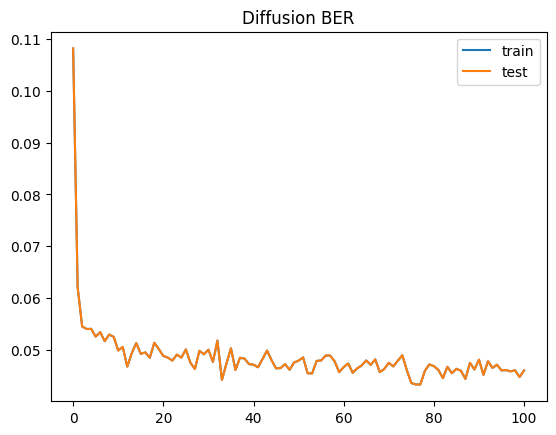

In [28]:
import matplotlib.pyplot as plt
plt.plot(train_ber, label='train')
plt.plot(test_ber, label='test')
plt.legend()
plt.title('Diffusion BER')
file_jpg = ".jpg"
file_jpg_name = f"{file_name_prefix}_{formatted_datetime}{file_jpg}"
plt.savefig(file_jpg_name)

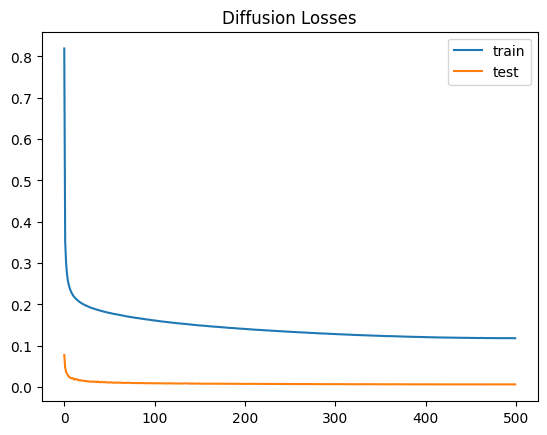

In [29]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.legend()
plt.title('Diffusion Losses')
file_jpg = ".png"
file_jpg_name = f"{file_name_prefix}_{formatted_datetime}{file_jpg}"
plt.savefig(file_jpg_name)

# Simulation

In [30]:
total = sum([param.nelement() for param in dnn.parameters()])

trainable_num = sum(p.numel() for p in dnn.parameters() if p.requires_grad)

print("Number of parameter: %.2f" % (total))

print("Number of trainable_parameter: %.2f" % (trainable_num))

params = list(dnn.parameters())
k = 0
for i in params:
    l = 1
    print("Structure：" + str(list(i.size())))
    for j in i.size():
        l *= j
    print("Parameter number：" + str(l))
    k = k + l
print("Total parameter number：" + str(k))

Number of parameter: 1003152.00
Number of trainable_parameter: 1003152.00
Structure：[128, 128]
Parameter number：16384
Structure：[128]
Parameter number：128
Structure：[128, 128]
Parameter number：16384
Structure：[128]
Parameter number：128
Structure：[256, 16]
Parameter number：4096
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[256, 256]
Parameter number：65536
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[256, 256]
Parameter number：65536
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[256]
Parameter number：256
Structure：[128, 256]
Parameter number：32768
Structure：[128]
Parameter number：128
Structure：[8, 128]
Parameter number：1024
Structure：[8]
Parameter number：8
Structure：[256, 8]
Parameter number：2048
Structure：[256]
Parameter number：256
Structure：[256, 512]
Parameter number：131072
Structure：[256]
Paramet

In [31]:
def fails(list1, list2):
    """返回比特错误数."""
    return pcf.np.count_nonzero(list1 - list2)

In [32]:
import polar_codes.polar_coding_functions as pcf
import time

EbN0 = 8                      # 测 0-7 dB
Frame_number = 10000          # 小规模问题, 多帧测量
NUM_INFER_STEPS = 50
SIM_BATCH = 1024

dnn.eval()

# 诊断
print("=" * 60)
print(f"DIAGNOSTIC PAC({N},{K}) (CFG scale={SAMPLE_GUIDANCE})")
print("=" * 60)
sinrdb_test = 3
channel_test  = BpskAwgnChannel(sinrdb_test, R)
rprofile_test = rateprofile(N, K, sinrdb_test)
code_test     = PACCode(N=N, K=K, construct='rm-polar', dSNR=sinrdb_test, rprofile=rprofile_test)

U_test = np.zeros((32, K), dtype=np.uint8)
Y_test_arr = np.zeros((32, N), dtype=np.float32)
for b in range(32):
    u_msg = (np.random.rand(K) > 0.5).astype('uint8')
    x_msg = code_test.pac_encode(u_msg, conv_gen, mem)
    y_msg = channel_test.cal_llr(channel_test.transmit(channel_test.modulate(x_msg)))
    U_test[b] = u_msg
    Y_test_arr[b] = y_msg.astype(np.float32)
y_cond_test = torch.tensor(Y_test_arr, device=device)

t0 = time.time()
u_hat_test = conditional_diffusion_sample(
    dnn.base_model, y_cond_test, diffusion_scheduler,
    num_inference_steps=NUM_INFER_STEPS, K_dim=K, device=device,
    guidance_scale=SAMPLE_GUIDANCE,
    use_amp=USE_AMP, amp_dtype=AMP_DTYPE)
if device.type == 'cuda':
    torch.cuda.synchronize()
sample_time = time.time() - t0

print(f"50-step diffusion on batch=32: {sample_time:.4f}s ({sample_time/32*1000:.2f} ms/frame)")
print(f"u_hat stats: mean={u_hat_test.mean().item():.3f}, "
      f"std={u_hat_test.std().item():.3f}")

u_hat_bin = (u_hat_test < 0).long().cpu().numpy().astype(np.int64)
n_correct = sum(1 for b in range(32) if np.array_equal(u_hat_bin[b], U_test[b].astype(np.int64)))
err_rate  = (u_hat_bin != U_test.astype(np.int64)).sum() / (32 * K)
print(f"诊断 (32 帧 @ {sinrdb_test} dB): {n_correct}/32 帧完全正确, BER={err_rate:.4f}")

print()
print("CFG guidance scale 扫描 (32 帧 @ 3 dB):")
for gs in [1.0, 1.5, 2.0, 3.0, 5.0]:
    u_hat_gs = conditional_diffusion_sample(
        dnn.base_model, y_cond_test, diffusion_scheduler,
        num_inference_steps=NUM_INFER_STEPS, K_dim=K, device=device,
        guidance_scale=gs,
        use_amp=USE_AMP, amp_dtype=AMP_DTYPE)
    u_hat_bin_gs = (u_hat_gs < 0).long().cpu().numpy().astype(np.int64)
    err_rate_gs = (u_hat_bin_gs != U_test.astype(np.int64)).sum() / (32 * K)
    print(f"  scale={gs:.1f} -> BER={err_rate_gs:.4f}")
print("=" * 60)
print()

# 正式仿真
results = []
for j in range(EbN0):
    fer = 0
    ber = 0
    sinrdb = j
    channel  = BpskAwgnChannel(sinrdb, R)
    rprofile = rateprofile(N, K, sinrdb)
    code     = PACCode(N=N, K=K, construct='rm-polar', dSNR=sinrdb, rprofile=rprofile)

    sum_time = 0.0
    n_done   = 0

    while n_done < Frame_number:
        cur_B = min(SIM_BATCH, Frame_number - n_done)
        U_batch = np.zeros((cur_B, K), dtype=np.uint8)
        Y_batch = np.zeros((cur_B, N), dtype=np.float32)
        for b in range(cur_B):
            u_message = np.asarray([0 if np.random.random_sample() > 0.5 else 1 for _ in range(K)], dtype='uint8')
            x_message = code.pac_encode(u_message, conv_gen, mem)
            to_message   = channel.modulate(x_message)
            from_message = channel.transmit(to_message)
            if LLR_Model == 'Hard':
                y_message = channel.demodulate(from_message)
            elif LLR_Model == 'Dire':
                y_message = from_message
            elif LLR_Model == 'Calc':
                y_message = channel.cal_llr(from_message)
            U_batch[b] = u_message
            Y_batch[b] = y_message.astype(np.float32)

        y_cond_t = torch.tensor(Y_batch, device=device)

        t0 = time.time()
        u_hat = conditional_diffusion_sample(
            dnn.base_model, y_cond_t, diffusion_scheduler,
            num_inference_steps=NUM_INFER_STEPS, K_dim=K, device=device,
            guidance_scale=SAMPLE_GUIDANCE,
            use_amp=USE_AMP, amp_dtype=AMP_DTYPE)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        sum_time += (time.time() - t0)

        u_hat_bin = (u_hat < 0).long().cpu().numpy().astype(np.int64)
        for b in range(cur_B):
            ub = U_batch[b].astype(np.int64)
            uh = u_hat_bin[b]
            ber += fails(ub, uh)
            if not pcf.np.array_equal(ub, uh):
                fer += 1
        n_done += cur_B

    fer_rate = fer / Frame_number
    ber_rate = ber / (Frame_number * K)
    avg_time = sum_time / Frame_number
    results.append((sinrdb, fer_rate, ber_rate, avg_time))
    print(f"Eb/N0: {j} | FER: {fer_rate:.4e} | BER: {ber_rate:.4e} | avg time: {avg_time*1000:.3f} ms/frame")

print("\nDone.")

DIAGNOSTIC PAC(16,8) (CFG scale=2.0)
50-step diffusion on batch=32: 0.0817s (2.55 ms/frame)
u_hat stats: mean=-0.009, std=1.002
诊断 (32 帧 @ 3 dB): 31/32 帧完全正确, BER=0.0156

CFG guidance scale 扫描 (32 帧 @ 3 dB):
  scale=1.0 -> BER=0.0391
  scale=1.5 -> BER=0.0312
  scale=2.0 -> BER=0.0156
  scale=3.0 -> BER=0.0312
  scale=5.0 -> BER=0.0000

Eb/N0: 0 | FER: 3.2720e-01 | BER: 1.7922e-01 | avg time: 0.083 ms/frame
Eb/N0: 1 | FER: 1.9380e-01 | BER: 1.0929e-01 | avg time: 0.082 ms/frame
Eb/N0: 2 | FER: 1.0620e-01 | BER: 5.9225e-02 | avg time: 0.082 ms/frame
Eb/N0: 3 | FER: 4.6000e-02 | BER: 2.6337e-02 | avg time: 0.081 ms/frame
Eb/N0: 4 | FER: 1.8400e-02 | BER: 1.0937e-02 | avg time: 0.080 ms/frame
Eb/N0: 5 | FER: 4.3000e-03 | BER: 2.6125e-03 | avg time: 0.081 ms/frame
Eb/N0: 6 | FER: 8.0000e-04 | BER: 4.8750e-04 | avg time: 0.081 ms/frame
Eb/N0: 7 | FER: 2.0000e-04 | BER: 1.5000e-04 | avg time: 0.081 ms/frame

Done.


In [ ]:
import polar_codes.polar_coding_functions as pcf
import matplotlib.pyplot as plt
import numpy as np

snr_values = [r[0] for r in results]
fer_values = [r[1] for r in results]
ber_values = [r[2] for r in results]
time_values = [r[3] for r in results]

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.semilogy(snr_values, fer_values, 'ro-', label='FER (Diffusion)', linewidth=2, markersize=8)
plt.semilogy(snr_values, ber_values, 'bs-', label='BER (Diffusion)', linewidth=2, markersize=8)
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('Error Rate')
plt.title(f'Dual-Head Conditional Diffusion FER and BER vs Eb/N0  (PAC({N},{K}))')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(snr_values, time_values, 'g^-', label='Avg Decoding Time', linewidth=2, markersize=8)
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('Time (s)')
plt.title(f'Diffusion Avg Decoding Time vs Eb/N0  (PAC({N},{K}))')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

plt.tight_layout()
plt.savefig(f'BER_PAC{N}_{K}_DualHeadDiff.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPerformance Summary for PAC({N},{K}):")
print("Eb/N0(dB)\tFER\t\tBER\t\tAvg Time(ms)")
print("-" * 60)
for r in results:
    print(f"{r[0]}\t\t{r[1]:.2e}\t{r[2]:.2e}\t{r[3]*1000:.3f}")

# Save CSV
np.savetxt(f'results_PAC{N}_{K}_DualHeadDiff.csv',
           np.array(results), delimiter=',',
           header='EbN0,FER,BER,AvgTime', comments='', fmt='%.6f')